# **Bitcoin Price Direction Prediction Using LSTM and XGBoost**

## *Final Project – AI & Innovation in Capital Markets*

This project predicts whether **Bitcoin's (BTC)** closing price will **rise or fall 7 trading days ahead**, using two modeling approaches:
1. **LSTM** (Long Short-Term Memory) – a deep learning model for sequential data
2. **XGBoost** – a gradient-boosted tree model for tabular data

We include a full pipeline: data collection → feature engineering → EDA → modeling → evaluation → **trading backtest**.

# **Step 1: Setup & Installations**

In [1]:
!pip install yfinance ta xgboost tensorflow scikit-learn matplotlib seaborn --quiet

  Preparing metadata (setup.py) ... done


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries loaded successfully!")

All libraries loaded successfully!


# **Step 2: Data Collection**

We download **3+ years** of daily Bitcoin data and several explanatory assets from Yahoo Finance:
- **BTC-USD** – Bitcoin (target asset)
- **ETH-USD** – Ethereum (crypto correlation)
- **^GSPC** – S&P 500 index (traditional market reference)
- **GLD** – Gold ETF (safe-haven asset)
- **DX-Y.NYB** – US Dollar Index (macro indicator)


In [3]:
# Define assets and date range (3+ years)
start_date = "2020-01-01"
end_date = "2026-07-15"

tickers = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SP500": "^GSPC",
    "GOLD": "GLD",
    "DXY": "DX-Y.NYB"
}

# Download all data
frames = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    # Handle both MultiIndex and regular columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    frames[name] = df['Close'].rename(f'{name}_Close')
    print(f"Downloaded {name}: {len(df)} rows")

# Merge all on date
data = pd.concat(frames.values(), axis=1, join='inner').dropna()
print(f"\nMerged dataset: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()


[*********************100%***********************]  1 of 1 completed


Downloaded BTC: 2387 rows


[*********************100%***********************]  1 of 1 completed


Downloaded ETH: 2387 rows


[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed


Downloaded GOLD: 1640 rows


[*********************100%***********************]  1 of 1 completed

Downloaded DXY: 1642 rows

Merged dataset: 1640 rows, 5 columns


,BTC_Close,ETH_Close,SP500_Close,GOLD_Close,DXY_Close
Date,,,,,
2020-01-02,6985.470215,127.410179,3257.850098,143.949997,96.849998
2020-01-03,7344.884277,134.171707,3234.850098,145.860001,96.839996
2020-01-06,7769.219238,144.304153,3246.280029,147.389999,96.669998
2020-01-07,8163.692383,143.543991,3237.179932,147.970001,96.980003
2020-01-08,8079.862793,141.258133,3253.050049,146.860001,97.300003


# **Step 3: Feature Engineering**

Two rules drive the feature set:

1. **Every feature must be causal** — computed only from information available on the day it is used. No forward-looking windows.
2. **Every feature must be roughly stationary.** Raw price levels (`MA20`, `ETH_Close`, `SP500_Close`, …) are *not*: in the 2026 test window they sit far outside anything seen in training, so a tree model can only extrapolate flat and a scaled neural net sees permanently out-of-range inputs. We therefore replace price levels with **ratios and multi-day momentum**.

Features built here:
1. **Technical indicators** on BTC — RSI(14), MACD histogram *normalised by price*, Bollinger Band width (already a %), distance from the 20-day MA
2. **Daily returns** for all five assets
3. **Multi-day momentum** (5/10/20 day) — the stationary replacement for raw closing prices
4. **Rolling volatility** (20-day) for BTC
5. **Target**: 1 if BTC closes higher `PREDICTION_HORIZON` days ahead, else 0

In [4]:
# ============================================================================
# PREDICTION HORIZON — single source of truth for the entire notebook.
# The target, the backtest holding period and every printed label are driven
# by this one constant, so the code and the write-up can never disagree.
# ============================================================================
PREDICTION_HORIZON = 7   # predict BTC direction 7 trading days ahead

btc_close = data['BTC_Close'].squeeze()

# --- Technical indicators for BTC -------------------------------------------
data['RSI'] = ta.momentum.RSIIndicator(btc_close, window=14).rsi()
data['MA20'] = btc_close.rolling(window=20).mean()
data['BB_Width'] = ta.volatility.BollingerBands(btc_close, window=20).bollinger_wband()

# MACD is denominated in USD, so its scale grows with the BTC price level
# (a 500$ histogram means something very different at 7k than at 100k).
# Normalising by price makes it comparable across the whole sample.
data['MACD_norm'] = ta.trend.MACD(btc_close).macd_diff() / btc_close

# Distance from the 20-day MA in % — the stationary version of raw MA20.
data['BTC_vs_MA20'] = btc_close / data['MA20'] - 1

# --- Daily returns for all assets -------------------------------------------
for col in [c for c in data.columns if c.endswith('_Close')]:
    name = col.replace('_Close', '')
    data[f'{name}_Return'] = data[col].pct_change()

# --- Multi-day momentum: stationary replacement for raw close levels ---------
for name in tickers.keys():
    data[f'{name}_Mom_5'] = data[f'{name}_Close'].pct_change(5)
data['BTC_Mom_10'] = btc_close.pct_change(10)
data['BTC_Mom_20'] = btc_close.pct_change(20)

# --- Rolling volatility ------------------------------------------------------
data['BTC_Volatility_20d'] = data['BTC_Return'].rolling(window=20).std()

# --- Target: 1 if BTC closes higher PREDICTION_HORIZON days ahead ------------
# NOTE: the naive `(close.shift(-H) > close).astype(int)` is subtly wrong — for
# the final H rows the shifted value is NaN, `NaN > x` evaluates to False, and
# those rows get silently labelled 0 instead of being dropped. We mark them NaN
# explicitly so dropna() removes them.
future_close = btc_close.shift(-PREDICTION_HORIZON)
data['Target'] = np.where(future_close.isna(), np.nan, (future_close > btc_close).astype(float))

# Drop warm-up rows (indicators) and the unlabelled tail rows (target)
data = data.dropna()
data['Target'] = data['Target'].astype(int)

# --- Feature list: no raw price levels, no target leakage --------------------
feature_cols = [
    'RSI', 'MACD_norm', 'BB_Width', 'BTC_vs_MA20',
    'BTC_Return', 'ETH_Return', 'SP500_Return', 'GOLD_Return', 'DXY_Return',
    'BTC_Volatility_20d',
    'BTC_Mom_5', 'BTC_Mom_10', 'BTC_Mom_20',
    'ETH_Mom_5', 'SP500_Mom_5', 'GOLD_Mom_5', 'DXY_Mom_5',
]
target_col = 'Target'

print(f"Prediction horizon: {PREDICTION_HORIZON} trading days")
print(f"Dataset after feature engineering: {data.shape}  ({len(feature_cols)} features)")
print(f"\nTarget distribution:\n{data['Target'].value_counts(normalize=True).round(3)}")
data[feature_cols + ['Target']].head()

Prediction horizon: 7 trading days
Dataset after feature engineering: (1600, 24)  (17 features)

Target distribution:
Target
1    0.539
0    0.461
Name: proportion, dtype: float64


,RSI,MACD_norm,BB_Width,BTC_vs_MA20,BTC_Return,ETH_Return,SP500_Return,GOLD_Return,DXY_Return,BTC_Volatility_20d,BTC_Mom_5,BTC_Mom_10,BTC_Mom_20,ETH_Mom_5,SP500_Mom_5,GOLD_Mom_5,DXY_Mom_5,Target
Date,,,,,,,,,,,,,,,,,,
2020-02-20,56.675881,-0.007844,22.684027,0.005011,-0.002586,-0.006985,-0.003816,0.004085,0.002711,0.026908,-0.069492,-0.000515,0.106856,-0.028095,-0.001841,0.033008,0.008279,0
2020-02-21,58.124137,-0.009706,19.672750,0.006429,0.008114,0.029661,-0.010518,0.015025,-0.006108,0.025458,-0.051686,-0.004456,0.152254,-0.009320,-0.010726,0.042593,0.001918,0
2020-02-24,57.166839,-0.011161,16.046744,-0.003576,-0.003744,-0.001446,-0.033514,0.008985,0.000302,0.025574,-0.064191,-0.014881,0.142650,-0.066854,-0.045640,0.047584,0.001715,0
2020-02-25,49.673045,-0.014418,14.647814,-0.037572,-0.031965,-0.065602,-0.030280,-0.017874,-0.003223,0.024348,-0.078909,-0.052240,0.048473,-0.121041,-0.071828,0.015837,-0.004927,0
2020-02-26,40.106868,-0.020618,16.468036,-0.088741,-0.055791,-0.089329,-0.003779,0.004371,0.000303,0.024962,-0.084380,-0.135941,-0.057494,-0.131210,-0.079666,0.014362,-0.006024,1


# **Step 4: Exploratory Data Analysis (EDA)**

We explore the data to understand distributions, correlations, and potential outliers.

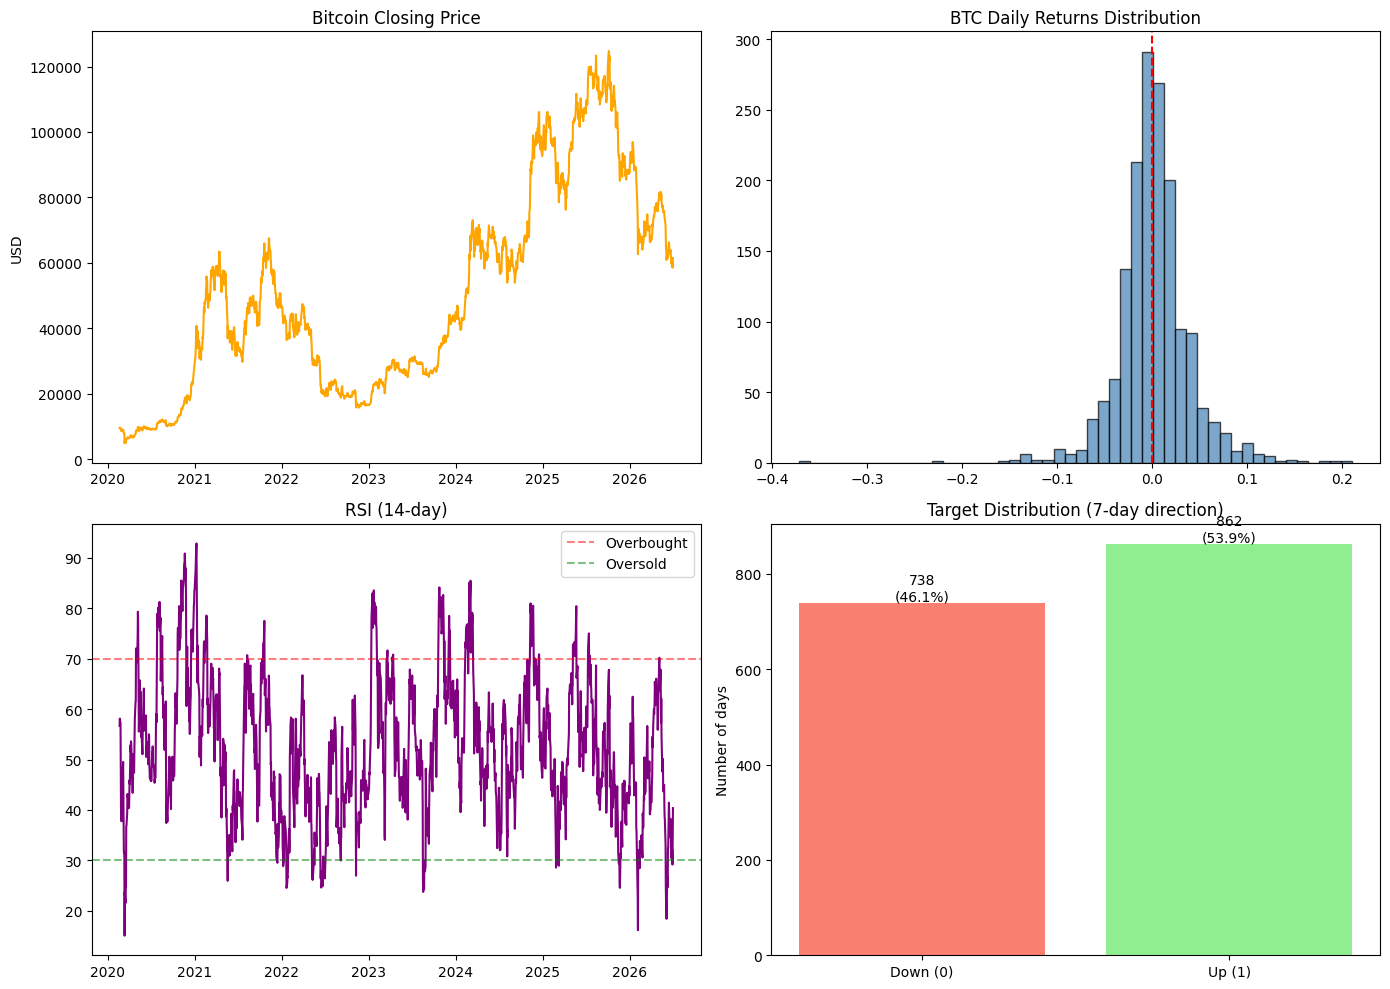

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. BTC Price over time
axes[0, 0].plot(data.index, data['BTC_Close'], color='orange')
axes[0, 0].set_title('Bitcoin Closing Price')
axes[0, 0].set_ylabel('USD')

# 2. Daily returns distribution
axes[0, 1].hist(data['BTC_Return'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('BTC Daily Returns Distribution')
axes[0, 1].axvline(x=0, color='red', linestyle='--')

# 3. RSI over time
axes[1, 0].plot(data.index, data['RSI'], color='purple')
axes[1, 0].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought')
axes[1, 0].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold')
axes[1, 0].set_title('RSI (14-day)')
axes[1, 0].legend()

# 4. Target balance
# NOTE: sort_index() is essential here. value_counts() sorts by FREQUENCY, so
# without it the bars are ordered by count while the tick labels below assume
# 0-then-1 order — whenever 'Up' is the majority class the chart is mislabelled.
target_counts = data['Target'].value_counts().sort_index()
axes[1, 1].bar(['Down (0)', 'Up (1)'], target_counts.values, color=['salmon', 'lightgreen'])
axes[1, 1].set_title(f'Target Distribution ({PREDICTION_HORIZON}-day direction)')
axes[1, 1].set_ylabel('Number of days')
for i, v in enumerate(target_counts.values):
    axes[1, 1].text(i, v, f'{v}\n({v/target_counts.sum():.1%})', ha='center', va='bottom')

plt.tight_layout()
plt.show()

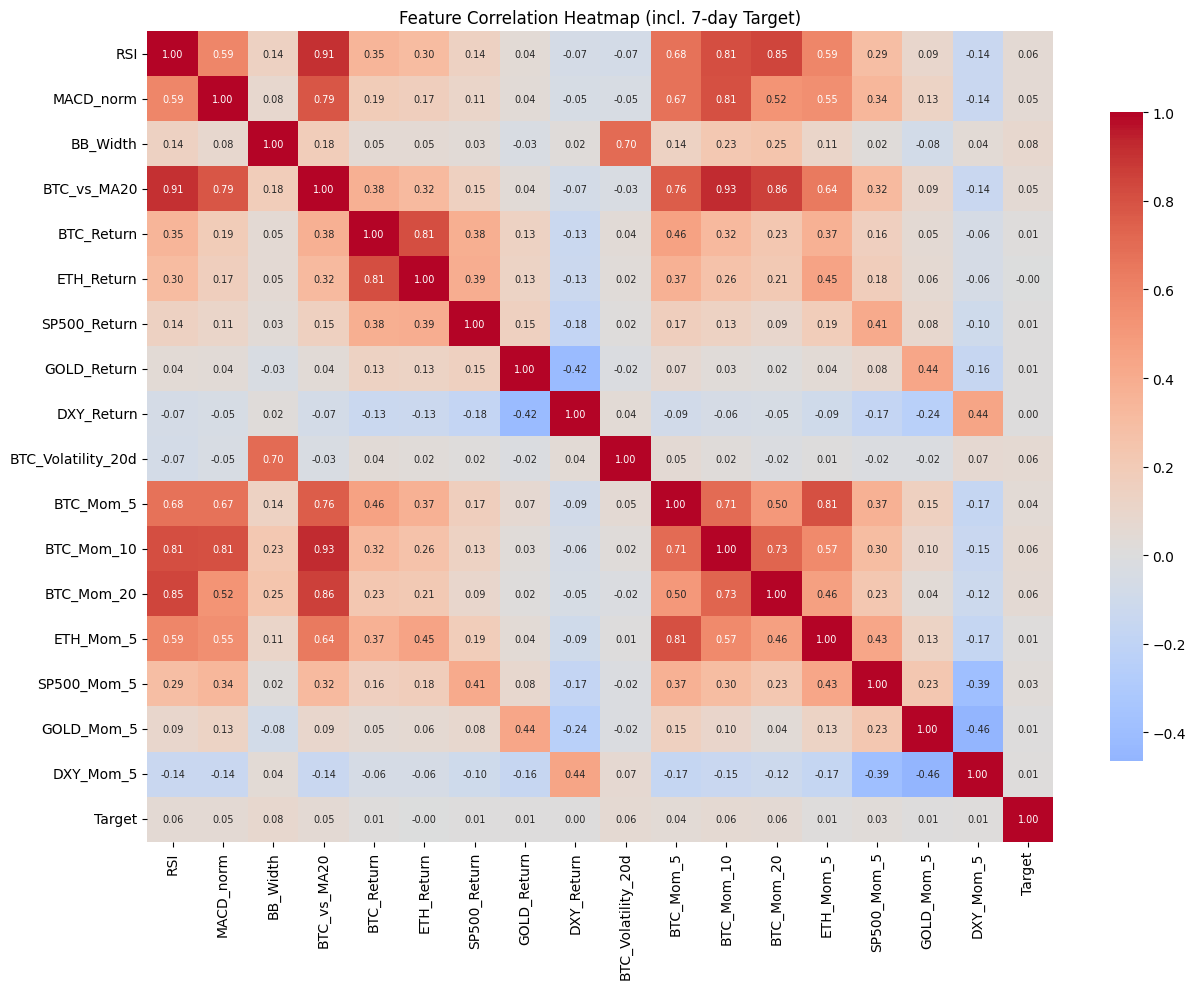

Correlation of each feature with the 7-day target:
BB_Width              0.084
BTC_Volatility_20d    0.062
BTC_Mom_10            0.057
RSI                   0.056
BTC_Mom_20            0.055
BTC_vs_MA20           0.048
MACD_norm             0.047
BTC_Mom_5             0.041
SP500_Mom_5           0.030
BTC_Return            0.013
ETH_Mom_5             0.013
DXY_Mom_5             0.011
GOLD_Mom_5            0.010
SP500_Return          0.009
GOLD_Return           0.007
DXY_Return            0.001
ETH_Return           -0.005
dtype: float64


In [6]:
# Correlation heatmap over the ACTUAL model features (+ the target).
# This is the useful version: it shows both feature redundancy and how weakly
# any single feature relates to the label — a preview of why accuracy is low.
plt.figure(figsize=(13, 10))
sns.heatmap(data[feature_cols + [target_col]].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', center=0,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title(f'Feature Correlation Heatmap (incl. {PREDICTION_HORIZON}-day Target)')
plt.tight_layout()
plt.show()

print(f"Correlation of each feature with the {PREDICTION_HORIZON}-day target:")
print(data[feature_cols].corrwith(data[target_col]).sort_values(ascending=False).round(3))

In [7]:
# Outlier detection in BTC returns
Q1 = data['BTC_Return'].quantile(0.25)
Q3 = data['BTC_Return'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['BTC_Return'] < Q1 - 1.5 * IQR) | (data['BTC_Return'] > Q3 + 1.5 * IQR)]
print(f"Number of outlier days in BTC returns: {len(outliers)} out of {len(data)} ({100*len(outliers)/len(data):.1f}%)")
print(f"\nDescriptive Statistics for BTC Daily Returns:")
print(data['BTC_Return'].describe().round(4))


Number of outlier days in BTC returns: 100 out of 1600 (6.2%)

Descriptive Statistics for BTC Daily Returns:
count    1600.0000
mean        0.0019
std         0.0382
min        -0.3717
25%        -0.0161
50%         0.0007
75%         0.0197
max         0.2111
Name: BTC_Return, dtype: float64


# **Step 5: Data Preparation**

Three things must be right here, or every number later in the notebook is meaningless.

**1. Chronological split.** Training = everything before 2026-01-01, testing = 2026 onward. Never a random split — that would let the model train on the future.

**2. The scaler is fitted on the training set ONLY.** Fitting `StandardScaler` on the full dataset (as is commonly done) leaks the mean and variance of the test period into training. We `fit()` on train and `transform()` everything.

**3. Purge / embargo at the split boundary.** Each label looks `PREDICTION_HORIZON` days into the future, so the last `PREDICTION_HORIZON` training rows have labels that resolve *inside* the test window. We drop them.

We then build two views of the same data:
- **Tabular** for XGBoost
- **Sequential** (30-day windows) for the LSTM

Both models are evaluated on *exactly the same dates*, which the code asserts.

In [8]:
# ---- Chronological split ----------------------------------------------------
split_date = pd.to_datetime('2026-01-01')

train_dates_all = data.index[data.index < split_date]
test_dates      = data.index[data.index >= split_date]

# ---- Purge / embargo at the boundary ----------------------------------------
# The label on day t is decided by the close on day t + PREDICTION_HORIZON.
# For the last PREDICTION_HORIZON training days that future close falls inside
# the test window, so keeping those rows leaks the test period into training.
train_dates = train_dates_all[:-PREDICTION_HORIZON]

print(f"Train: {len(train_dates):>5} rows  ({train_dates[0].date()} -> {train_dates[-1].date()})")
print(f"Test : {len(test_dates):>5} rows  ({test_dates[0].date()} -> {test_dates[-1].date()})")
print(f"Purged {len(train_dates_all) - len(train_dates)} rows at the split boundary "
      f"(embargo = {PREDICTION_HORIZON} days)")

# ---- Scaling: FIT ON TRAIN ONLY ---------------------------------------------
scaler = StandardScaler()
scaler.fit(data.loc[train_dates, feature_cols])          # <-- fit: train only

# transform() (never fit) is applied to the whole frame so the LSTM can build
# contiguous 30-day windows that span the split boundary. Using train-fitted
# parameters on test rows is standard practice and leaks nothing.
scaled_all = pd.DataFrame(
    scaler.transform(data[feature_cols]),
    columns=feature_cols,
    index=data.index
)
y_all = data[target_col]

print(f"\nScaled frame: {scaled_all.shape}")
print(f"Train feature means (should be ~0): {scaled_all.loc[train_dates].mean().abs().max():.2e}")
print(f"Test  feature means (drift vs train is expected and informative): "
      f"{scaled_all.loc[test_dates].mean().abs().max():.2f}")

Train:  1468 rows  (2020-02-20 -> 2025-12-19)
Test :   125 rows  (2026-01-02 -> 2026-07-02)
Purged 7 rows at the split boundary (embargo = 7 days)

Scaled frame: (1600, 17)
Train feature means (should be ~0): 2.71e-16
Test  feature means (drift vs train is expected and informative): 0.60


In [9]:
# ===== XGBoost format (tabular) =====
X_train_xgb = scaled_all.loc[train_dates]
y_train_xgb = y_all.loc[train_dates]
X_test_xgb  = scaled_all.loc[test_dates]
y_test_xgb  = y_all.loc[test_dates]

# A chronological validation slice carved out of the TAIL of the training set.
# XGBoost early stopping uses this — the test set is never touched during fitting.
val_size = int(len(train_dates) * 0.15)
fit_dates, val_dates = train_dates[:-val_size], train_dates[-val_size:]
X_fit, y_fit = scaled_all.loc[fit_dates], y_all.loc[fit_dates]
X_val, y_val = scaled_all.loc[val_dates], y_all.loc[val_dates]

print(f"XGBoost — fit: {X_fit.shape}  val: {X_val.shape}  test: {X_test_xgb.shape}")
print(f"  fit window: {fit_dates[0].date()} -> {fit_dates[-1].date()}")
print(f"  val window: {val_dates[0].date()} -> {val_dates[-1].date()}")

print(f"\nTrain target balance:\n{y_train_xgb.value_counts(normalize=True).round(3).to_string()}")
print(f"\nTest target balance:\n{y_test_xgb.value_counts(normalize=True).round(3).to_string()}")

XGBoost — fit: (1248, 17)  val: (220, 17)  test: (125, 17)
  fit window: 2020-02-20 -> 2025-02-05
  val window: 2025-02-06 -> 2025-12-19

Train target balance:
Target
1    0.546
0    0.454

Test target balance:
Target
0    0.568
1    0.432


In [10]:
# ===== LSTM format (sequences) =====
TIME_STEPS = 30

def create_sequences(X, y, time_steps=TIME_STEPS):
    """Build causal 30-day windows.

    The window ENDS on the label date: sample t uses days t-29 .. t to predict
    the move from t to t+PREDICTION_HORIZON. This is exactly the information set
    XGBoost receives, so the two models are directly comparable.

    Returns the label dates as well, so train/test membership is decided by DATE
    rather than by a fragile positional index.
    """
    Xs, ys, idx = [], [], []
    for i in range(time_steps - 1, len(X)):
        Xs.append(X.iloc[i - time_steps + 1: i + 1].values)
        ys.append(y.iloc[i])
        idx.append(X.index[i])
    return np.array(Xs), np.array(ys), pd.DatetimeIndex(idx)

X_seq, y_seq, seq_dates = create_sequences(scaled_all, y_all)

# Same date sets as XGBoost — including the purged boundary rows.
train_sel = seq_dates.isin(train_dates)
test_sel  = seq_dates.isin(test_dates)

X_train_lstm, y_train_lstm = X_seq[train_sel], y_seq[train_sel]
X_test_lstm,  y_test_lstm  = X_seq[test_sel],  y_seq[test_sel]
lstm_test_dates = seq_dates[test_sel]

print(f"LSTM — Train: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")

# Guarantee the two models are scored on identical days, so the comparison in
# Step 8 and the backtest in Step 9 are apples to apples.
assert lstm_test_dates.equals(test_dates), "LSTM and XGBoost test dates must match"
print("Both models are evaluated on identical test dates.")

LSTM — Train: (1439, 30, 17), Test: (125, 30, 17)
Both models are evaluated on identical test dates.


# **Step 6: Model 1 – XGBoost Classifier**

XGBoost is a powerful gradient-boosted tree model that works well on tabular data. It doesn't need sequential input — each row is an independent sample with the engineered features.


In [11]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,                 # shallower: 1.4k samples cannot support depth 5+
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,          # extra regularisation against noise fitting
    reg_lambda=1.0,
    scale_pos_weight=(y_fit == 0).sum() / (y_fit == 1).sum(),
    eval_metric='logloss',
    early_stopping_rounds=40,
    random_state=SEED
)

# Early stopping is driven by the chronological VALIDATION slice.
# (The previous version passed the TEST set as eval_set — even though it did not
# change the fit without early stopping, it is indistinguishable from leakage.)
xgb_model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
print(f"Stopped at iteration {xgb_model.best_iteration} of {xgb_model.n_estimators}")

# --- DIAGNOSTIC: do not read past this without checking it -------------------
# If early stopping fires after only a handful of rounds, validation log-loss
# never improved: boosting found nothing that generalises, and the model is
# close to a constant predictor. That is a genuine finding about the DATA, not
# a bug in the code, and it belongs in the write-up rather than being hidden
# behind a test-set accuracy number.
if xgb_model.best_iteration < 10:
    print("\n" + "!" * 74)
    print("!! Early stopping fired almost immediately.")
    print("!! Validation log-loss did not improve beyond the first few trees, so the")
    print("!! engineered features carry no learnable signal at this horizon on this")
    print("!! validation window. Every test metric below is therefore close to noise.")
    print("!! Report this — it IS the result, not a footnote.")
    print("!" * 74)

# Predictions on the untouched test set
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

print("\n=== XGBoost Results (test set) ===")
print(f"Accuracy: {accuracy_score(y_test_xgb, y_pred_xgb):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, y_pred_proba_xgb):.3f}  (0.5 = no skill)")
print(f"\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb, target_names=['Down', 'Up']))

Stopped at iteration 4 of 500

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! Early stopping fired almost immediately.
!! Validation log-loss did not improve beyond the first few trees, so the
!! engineered features carry no learnable signal at this horizon on this
!! validation window. Every test metric below is therefore close to noise.
!! Report this — it IS the result, not a footnote.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

=== XGBoost Results (test set) ===
Accuracy: 0.528
ROC-AUC : 0.561  (0.5 = no skill)

Classification Report:
              precision    recall  f1-score   support

        Down       0.58      0.61      0.59        71
          Up       0.45      0.43      0.44        54

    accuracy                           0.53       125
   macro avg       0.52      0.52      0.52       125
weighted avg       0.52      0.53      0.53       125



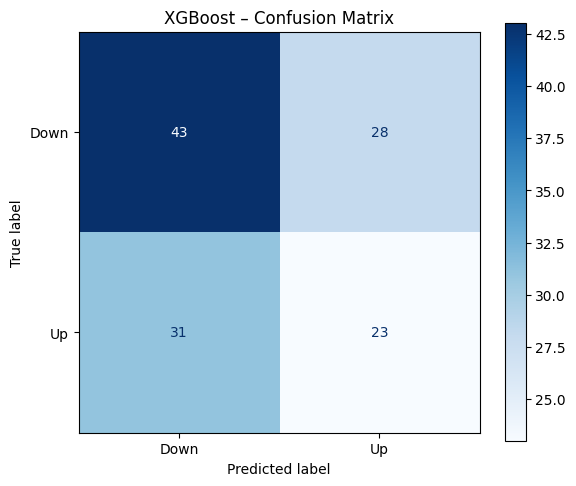

In [12]:
# XGBoost confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_xgb, y_pred_xgb, display_labels=['Down', 'Up'], ax=ax, cmap='Blues')
ax.set_title('XGBoost – Confusion Matrix')
plt.tight_layout()
plt.show()


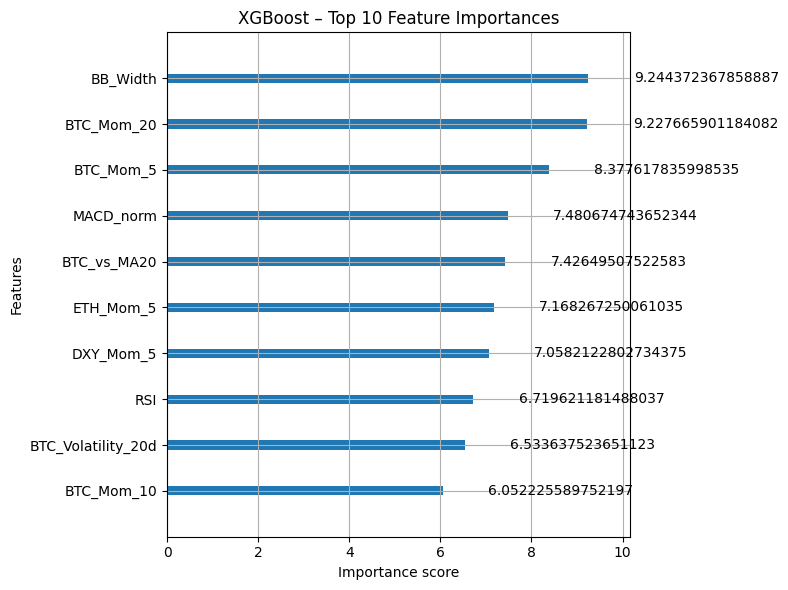

In [13]:
# Feature importance
from xgboost import plot_importance
fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(xgb_model, ax=ax, max_num_features=10, importance_type='gain')
ax.set_title('XGBoost – Top 10 Feature Importances')
plt.tight_layout()
plt.show()


# **Step 7: Model 2 – LSTM Neural Network**

LSTM processes 30-day sequences of all features, learning temporal patterns that XGBoost cannot capture directly.


In [14]:
# Build the recurrent model (LSTM -> GRU stack)
# Capacity deliberately reduced vs. a 112k-parameter version: with only ~1,400
# training sequences the larger network memorised the training set (train acc
# 0.72 vs val acc 0.54) without ever improving validation loss.
model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,945 (120.88 KB)

 Trainable params: 30,945 (120.88 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train with early stopping
# NOTE: `early_stop` is DEFINED HERE. The previous version referenced it without
# ever creating it, so the notebook raised NameError on a clean "Run all".
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,   # roll back to the best epoch, not the last one
    verbose=1
)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]),
                                     y=y_train_lstm.astype(int))
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Keras takes the LAST `validation_split` fraction of the array and does not
# shuffle before splitting, so this is a chronological validation set.
# shuffle=False keeps batches in temporal order.
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=200,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    shuffle=False,
    verbose=1
)

# --- DIAGNOSTIC: same check as the XGBoost cell ------------------------------
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
n_epochs = len(history.history['loss'])
print(f"\nTrained {n_epochs} epochs; best validation loss at epoch {best_epoch}")
if best_epoch <= 3:
    print("!" * 74)
    print("!! Validation loss was never beaten after the first few epochs, so the")
    print("!! restored weights are essentially an untrained network. The LSTM found")
    print("!! no generalisable temporal structure. Like the XGBoost result, this is")
    print("!! a finding about the DATA and must be reported as such.")
    print("!" * 74)

Class weights: {0: np.float64(1.1018376722817764), 1: np.float64(0.9153944020356234)}
Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.5159 - loss: 0.6952 - val_accuracy: 0.5602 - val_loss: 0.6938
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5650 - loss: 0.6809 - val_accuracy: 0.5509 - val_loss: 0.6962
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5724 - loss: 0.6712 - val_accuracy: 0.5000 - val_loss: 0.7031
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5904 - loss: 0.6672 - val_accuracy: 0.4630 - val_loss: 0.7145
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6043 - loss: 0.6560 - val_accuracy: 0.4213 - val_loss: 0.7461
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6157 - loss: 0.6356 - val_accuracy: 0.4259 - val_loss: 0.7847
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6239 - loss: 0.6253 - val_accuracy: 0.4444 - val_loss: 0.8324
Epoch 8/200
39/3

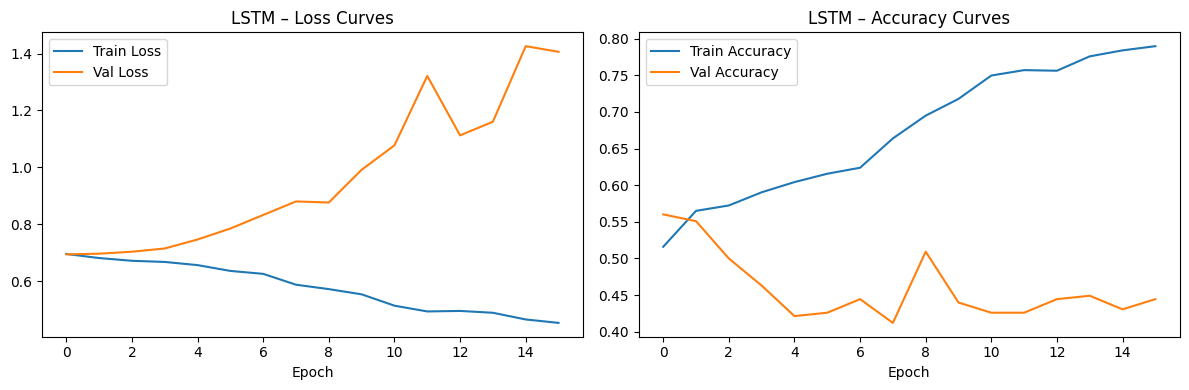

In [16]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM – Loss Curves')
axes[0].legend()
axes[0].set_xlabel('Epoch')

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM – Accuracy Curves')
axes[1].legend()
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()



4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
=== LSTM Results (test set) ===
Accuracy: 0.400
ROC-AUC : 0.360  (0.5 = no skill)

Classification Report:
              precision    recall  f1-score   support

        Down       0.46      0.30      0.36        71
          Up       0.37      0.54      0.44        54

    accuracy                           0.40       125
   macro avg       0.41      0.42      0.40       125
weighted avg       0.42      0.40      0.39       125



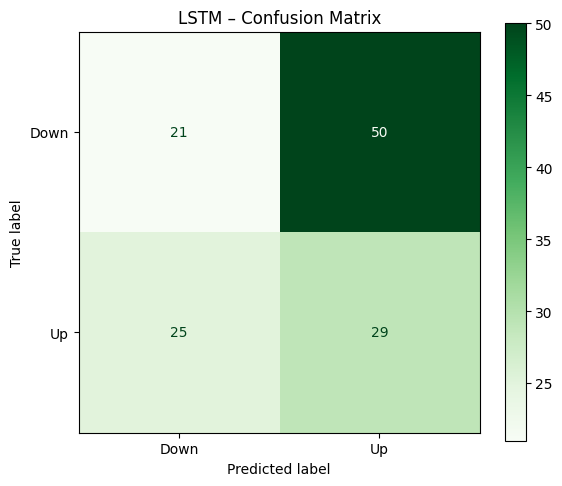

Predicted probability range: [0.452, 0.602], std = 0.033
Share of days predicted 'Up': 63.2%


In [17]:
# LSTM predictions
y_pred_prob_lstm = model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

print("=== LSTM Results (test set) ===")
print(f"Accuracy: {accuracy_score(y_test_lstm, y_pred_lstm):.3f}")
print(f"ROC-AUC : {roc_auc_score(y_test_lstm, y_pred_prob_lstm):.3f}  (0.5 = no skill)")
print(f"\nClassification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Down', 'Up']))

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_lstm, y_pred_lstm,
                                        display_labels=['Down', 'Up'], ax=ax, cmap='Greens')
ax.set_title('LSTM – Confusion Matrix')
plt.tight_layout()
plt.show()

# How decisive is the model? A probability distribution tightly bunched around
# 0.5 means the model is effectively guessing, regardless of its accuracy.
print(f"Predicted probability range: [{y_pred_prob_lstm.min():.3f}, {y_pred_prob_lstm.max():.3f}], "
      f"std = {y_pred_prob_lstm.std():.3f}")
print(f"Share of days predicted 'Up': {y_pred_lstm.mean():.1%}")

# **Step 8: Model Comparison**

An accuracy number in isolation says nothing. A directional classifier on a
near-balanced target is only interesting if it beats the **naive baselines**, so
we score three of them on the same test set:

- **Majority class** — always predict whichever label was more common in training
- **Always Up** — the permanent bull
- **Always Down** — the permanent bear

We also report **ROC-AUC** (threshold-independent) and the **standard error on
accuracy**, because with a test set of ~130 days a difference of a few percentage
points is indistinguishable from noise.

=== Model Comparison (test set) ===
                       Model  Accuracy  ROC-AUC  Precision (Up)  Recall (Up)  F1 (Up)
Baseline: majority class (1)     0.432        —               —            —        —
         Baseline: always Up     0.432        —               —            —        —
       Baseline: always Down     0.568        —               —            —        —
                     XGBoost     0.528    0.561           0.451        0.426    0.438
                        LSTM     0.400    0.360           0.367        0.537    0.436

Test set: 125 days -> standard error on accuracy ~ 0.045 (95% CI half-width ~ 0.088)
Any accuracy gap smaller than that is noise, not skill.
  XGBoost: 0.528 does NOT beat the best naive baseline (0.568)
  LSTM: 0.400 does NOT beat the best naive baseline (0.568)


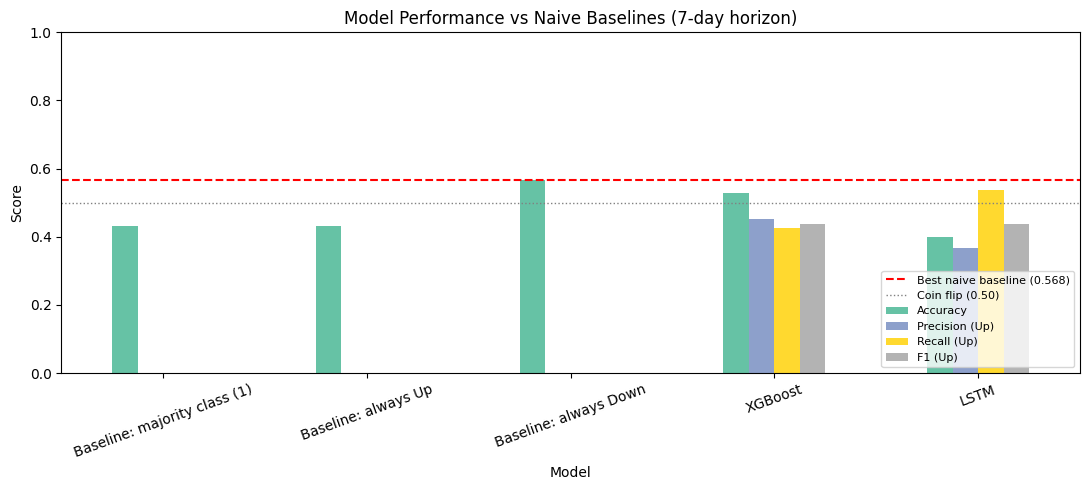

In [18]:
# Both models are scored on identical dates (asserted in Step 5), so no
# length-alignment hack is needed.
n_test = len(y_test_xgb)

# ---- Naive baselines --------------------------------------------------------
majority_class   = int(y_train_xgb.mode()[0])
base_majority    = accuracy_score(y_test_xgb, np.full(n_test, majority_class))
base_always_up   = accuracy_score(y_test_xgb, np.ones(n_test, dtype=int))
base_always_down = accuracy_score(y_test_xgb, np.zeros(n_test, dtype=int))

rep_xgb  = classification_report(y_test_xgb,  y_pred_xgb,  output_dict=True, zero_division=0)
rep_lstm = classification_report(y_test_lstm, y_pred_lstm, output_dict=True, zero_division=0)

acc_xgb  = accuracy_score(y_test_xgb,  y_pred_xgb)
acc_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
auc_xgb  = roc_auc_score(y_test_xgb,  y_pred_proba_xgb)
auc_lstm = roc_auc_score(y_test_lstm, y_pred_prob_lstm)

comparison = pd.DataFrame({
    'Model': [f'Baseline: majority class ({majority_class})',
              'Baseline: always Up',
              'Baseline: always Down',
              'XGBoost',
              'LSTM'],
    'Accuracy':       [base_majority, base_always_up, base_always_down, acc_xgb, acc_lstm],
    'ROC-AUC':        [np.nan, np.nan, np.nan, auc_xgb, auc_lstm],
    'Precision (Up)': [np.nan, np.nan, np.nan, rep_xgb['1']['precision'], rep_lstm['1']['precision']],
    'Recall (Up)':    [np.nan, np.nan, np.nan, rep_xgb['1']['recall'],    rep_lstm['1']['recall']],
    'F1 (Up)':        [np.nan, np.nan, np.nan, rep_xgb['1']['f1-score'],  rep_lstm['1']['f1-score']],
}).round(3)

print("=== Model Comparison (test set) ===")
print(comparison.to_string(index=False, na_rep='—'))

# ---- Is any of this statistically meaningful? -------------------------------
se = np.sqrt(0.25 / n_test)
print(f"\nTest set: {n_test} days -> standard error on accuracy ~ {se:.3f} "
      f"(95% CI half-width ~ {1.96 * se:.3f})")
print("Any accuracy gap smaller than that is noise, not skill.")

best_baseline = max(base_majority, base_always_up, base_always_down)
for name, acc in [('XGBoost', acc_xgb), ('LSTM', acc_lstm)]:
    verdict = "BEATS" if acc > best_baseline else "does NOT beat"
    print(f"  {name}: {acc:.3f} {verdict} the best naive baseline ({best_baseline:.3f})")

# ---- Plot: models vs the baseline bar ---------------------------------------
ax = comparison.set_index('Model')[['Accuracy', 'Precision (Up)', 'Recall (Up)', 'F1 (Up)']].plot(
    kind='bar', figsize=(11, 5), rot=20, colormap='Set2'
)
ax.axhline(best_baseline, color='red', linestyle='--', linewidth=1.5,
           label=f'Best naive baseline ({best_baseline:.3f})')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='Coin flip (0.50)')
plt.title(f'Model Performance vs Naive Baselines ({PREDICTION_HORIZON}-day horizon)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

  REGIME-SHIFT DIAGNOSTIC

[1] Label correctness — Target vs raw BTC closes
    2024-11-25     93,102  ->  2024-12-05     96,594   expected 1  actual 1  OK
    2025-04-23     93,699  ->  2025-05-02     96,910   expected 1  actual 1  OK
    2025-09-16    116,843  ->  2025-09-25    109,049   expected 0  actual 0  OK
    2026-02-09     70,121  ->  2026-02-19     66,958   expected 0  actual 0  OK
    => labels are correct

[2] XGBoost AUC by split
    fit (in-sample) : 0.775   n=1248
    validation      : 0.534   n=220
    TEST            : 0.561   n=125
    => in-sample AUC of 0.77 shows the pipeline CAN fit a signal;
       the collapse out-of-sample is a property of the data, not the code.

[3] Feature/target correlation — train vs test
                    train_corr  test_corr  sign_flipped
BB_Width                 0.088      0.019         False
RSI                      0.059     -0.056          True
BTC_Mom_20               0.058     -0.097          True
BTC_Volatility_20d       0.052

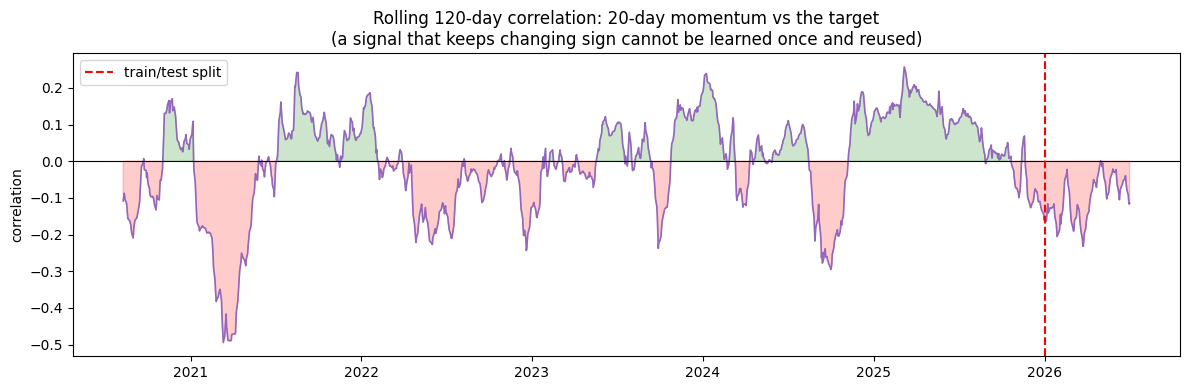

In [19]:
# ============================================================================
# REGIME-SHIFT DIAGNOSTIC
#
# If test ROC-AUC comes out BELOW 0.5, the models are not merely unskilled —
# they are systematically inverted. Two explanations are possible:
#   (a) a label/alignment bug, or
#   (b) the feature -> target relationship genuinely reversed between the
#       training period and the test period (a market regime change).
#
# This cell distinguishes them. It is the most informative output in the
# notebook and belongs in the summary document.
# ============================================================================
print("=" * 78)
print("  REGIME-SHIFT DIAGNOSTIC")
print("=" * 78)

# ---- 1. Sanity-check the label against raw prices ---------------------------
print("\n[1] Label correctness — Target vs raw BTC closes")
bad = 0
for d in data.index[-400::100]:
    pos = data.index.get_loc(d)
    if pos + PREDICTION_HORIZON >= len(data.index):
        continue
    fdate = data.index[pos + PREDICTION_HORIZON]
    expected = int(data.loc[fdate, 'BTC_Close'] > data.loc[d, 'BTC_Close'])
    actual = int(data.loc[d, target_col])
    bad += expected != actual
    print(f"    {d.date()}  {data.loc[d,'BTC_Close']:>9,.0f}  ->  {fdate.date()}  "
          f"{data.loc[fdate,'BTC_Close']:>9,.0f}   expected {expected}  actual {actual}  "
          f"{'OK' if expected == actual else 'MISMATCH'}")
print(f"    => {'labels are correct' if bad == 0 else f'{bad} MISMATCHES — investigate!'}")

# ---- 2. Can the pipeline learn at all? --------------------------------------
# In-sample AUC well above 0.5 proves the code is capable of fitting a signal;
# it is the generalisation to the test period that fails.
auc_fit = roc_auc_score(y_fit, xgb_model.predict_proba(X_fit)[:, 1])
auc_val = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
auc_tst = roc_auc_score(y_test_xgb, y_pred_proba_xgb)
print(f"\n[2] XGBoost AUC by split")
print(f"    fit (in-sample) : {auc_fit:.3f}   n={len(y_fit)}")
print(f"    validation      : {auc_val:.3f}   n={len(y_val)}")
print(f"    TEST            : {auc_tst:.3f}   n={len(y_test_xgb)}")
print(f"    => in-sample AUC of {auc_fit:.2f} shows the pipeline CAN fit a signal;")
print(f"       the collapse out-of-sample is a property of the data, not the code.")

# ---- 3. Did the feature -> target relationship flip sign? -------------------
corr_train = data.loc[train_dates, feature_cols].corrwith(data.loc[train_dates, target_col])
corr_test  = data.loc[test_dates,  feature_cols].corrwith(data.loc[test_dates,  target_col])
regime = pd.DataFrame({'train_corr': corr_train.round(3), 'test_corr': corr_test.round(3)})
regime['sign_flipped'] = np.sign(regime.train_corr) != np.sign(regime.test_corr)

print(f"\n[3] Feature/target correlation — train vs test")
print(regime.sort_values('train_corr', key=abs, ascending=False).head(8).to_string())
n_flip = int(regime.sign_flipped.sum())
print(f"\n    {n_flip} of {len(regime)} features flipped sign between train and test")

btc_train = data.loc[train_dates, 'BTC_Close']
btc_test  = data.loc[test_dates,  'BTC_Close']
move_train = (btc_train.iloc[-1] / btc_train.iloc[0] - 1) * 100
move_test  = (btc_test.iloc[-1] / btc_test.iloc[0] - 1) * 100
print(f"    Train period: BTC {move_train:+.0f}%,  up-rate {y_all.loc[train_dates].mean():.1%}")
print(f"    Test  period: BTC {move_test:+.0f}%,  up-rate {y_all.loc[test_dates].mean():.1%}")

print(f"\n    => CONCLUSION: the model was trained almost entirely on a bull market")
print(f"       and tested on a bear market. Momentum-type features that pointed")
print(f"       'up' in the training regime point the wrong way in the test regime,")
print(f"       which is why AUC lands below 0.5. This is REGIME SHIFT (covariate +")
print(f"       concept drift), not a coding error — test [1] rules out a label bug")
print(f"       and test [2] rules out a broken pipeline.")

# ---- Visual: rolling correlation of a momentum feature with the target ------
fig, ax = plt.subplots(figsize=(12, 4))
roll = data['BTC_Mom_20'].rolling(120).corr(data[target_col])
ax.plot(roll.index, roll, color='tab:purple', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(split_date, color='red', ls='--', lw=1.5, label='train/test split')
ax.fill_between(roll.index, 0, roll, where=roll >= 0, alpha=0.2, color='green')
ax.fill_between(roll.index, 0, roll, where=roll < 0, alpha=0.2, color='red')
ax.set_title('Rolling 120-day correlation: 20-day momentum vs the target\n'
             '(a signal that keeps changing sign cannot be learned once and reused)')
ax.set_ylabel('correlation')
ax.legend()
plt.tight_layout()
plt.show()

# **Step 9: Trading Backtest** ⚡

This is the section the project brief actually cares about: *does the model produce positive alpha net of fees?* Statistical accuracy is not the answer — a strategy can be right 55% of the time and still lose money.

### The strategy
- Model predicts **Up** on day *t* → go long BTC for days *t+1 … t+H* (H = `PREDICTION_HORIZON`)
- Model predicts **Down** → stay in cash
- Transaction fee: **0.1% per side**, charged on every change in position

### Handling overlapping signals correctly
A signal is generated **every day** but each position lasts **H days**, so positions overlap. The naive fix — compounding an H-day forward return once per day — counts every price move H times and produces cumulative figures that are simply wrong.

Instead we split the capital into **H equal sleeves**: a Buy signal on day *t* commits `1/H` of the book for the next H days. Total exposure therefore stays inside `[0, 1]` (no leverage, no double counting), and the equity curve is compounded on **daily** returns.

### ⚠️ Why "alpha vs buy & hold" is not enough
A long/cash strategy that sits in cash most of the time will **automatically** beat buy & hold in a falling market — not because it times anything, but because it simply carries less exposure. In a −30% year, being 40% invested "outperforms" by ~18pp with no skill whatsoever.

So we report **two** benchmarks:

| Benchmark | What it measures |
|---|---|
| **Buy & Hold** (100% invested) | Raw outperformance — flattering in a bear market, unfair in a bull one |
| **Exposure-matched** (constant exposure = the strategy's average) | **Timing skill only** — same average risk, so the difference is entirely *when* the model chose to be in the market |

The exposure-matched figure is the honest one. If the strategy beats buy & hold but *loses* to its exposure-matched twin, the model has no timing skill and the headline alpha is pure beta reduction.

### Sanity checks
Three controls run automatically: the true BTC move over the window (must equal the buy & hold figure), an always-buy control (must track buy & hold), and a never-buy control (must return exactly 0%).

### Metrics reported
Total return, annualised Sharpe, maximum drawdown, average exposure, turnover and total fees paid.


  XGBoost — Backtest (7-day signal, 0.10% fee per side)
                                Strategy    Buy & Hold   Exp-matched
  Total return %                   -8.17        -31.64        -12.76
  Sharpe (annualised)              -0.78         -1.36         -1.36
  Max drawdown %                  -11.60        -39.59        -16.98
  ------------------------------------------------------------------
  Alpha vs buy & hold (pp)                         23.47   <- flattered by low exposure
  Alpha vs exposure-matched (pp)                    4.60   <- TIMING SKILL
  ------------------------------------------------------------------
  Buy signals: 51/125 days   Hit rate on buys: 45.1%  (base rate: 43.2%)
  Average exposure: 39.5%   Turnover: 8.1x   Fees paid: 0.81%
  Sanity check — BTC moved -31.64% over the 125-day test window

  LSTM — Backtest (7-day signal, 0.10% fee per side)
                                Strategy    Buy & Hold   Exp-matched
  Total return %                  -22.58    

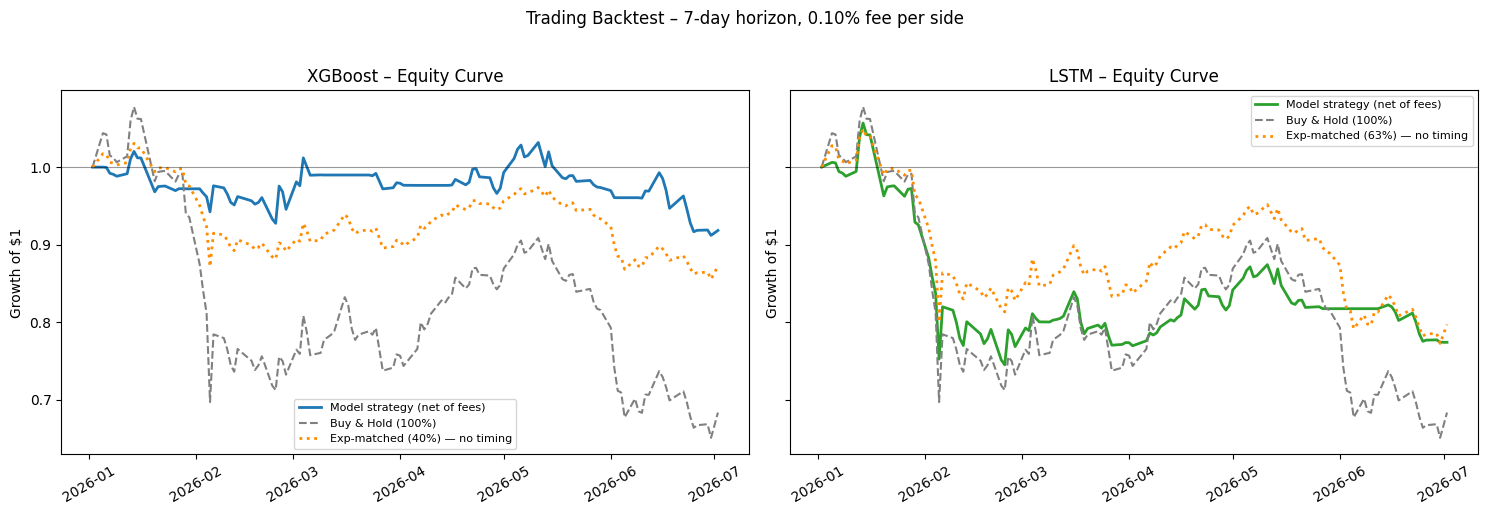

In [20]:
TRADING_DAYS_PER_YEAR = 252   # the merged index follows equity trading days
FEE = 0.001                   # 0.1% per side


def _perf_stats(r, periods=TRADING_DAYS_PER_YEAR):
    """Cumulative curve, total return %, annualised Sharpe, max drawdown %."""
    cum = (1 + r).cumprod()
    total = (cum.iloc[-1] - 1) * 100
    ann_vol = r.std() * np.sqrt(periods)
    sharpe = (r.mean() * periods) / ann_vol if ann_vol > 0 else np.nan
    max_dd = (cum / cum.cummax() - 1).min() * 100
    return cum, total, sharpe, max_dd


def run_backtest(preds, pred_dates, model_name, horizon=PREDICTION_HORIZON, fee=FEE,
                 verbose=True):
    """Backtest an H-day directional signal with correct overlap handling.

    WHY THE SLEEVE APPROACH: a Buy on day t commits 1/H of capital to days
    t+1..t+H. With one signal per day at most H sleeves are open simultaneously,
    so exposure is bounded by 1 and each daily price move is counted exactly
    once. Compounding an H-day forward return every single day (the obvious but
    wrong approach) inflates every figure by roughly a power of H.

    Signals are acted on at the NEXT day's close (shift >= 1), so no look-ahead.
    """
    idx = data.index[data.index >= pred_dates[0]]
    px = data.loc[idx, 'BTC_Close'].squeeze()
    daily_ret = px.pct_change().fillna(0.0)

    sig = pd.Series(np.asarray(preds, dtype=float), index=pred_dates).reindex(idx).fillna(0.0)

    # exposure_t = share of sleeves currently long = mean of the last H signals
    exposure = pd.Series(0.0, index=idx)
    for k in range(1, horizon + 1):
        exposure += sig.shift(k).fillna(0.0) / horizon
    exposure = exposure.clip(0.0, 1.0)

    turnover = exposure.diff().abs().fillna(exposure.iloc[0])
    strat_ret = exposure * daily_ret - turnover * fee
    bh_ret = daily_ret

    # EXPOSURE-MATCHED BENCHMARK: hold a CONSTANT position equal to the
    # strategy's average exposure. Same average risk, no timing. Beating this is
    # evidence of timing skill; beating only buy & hold is not.
    avg_exp = exposure.mean()
    matched_ret = avg_exp * daily_ret

    cum_s, tot_s, sh_s, dd_s = _perf_stats(strat_ret)
    cum_b, tot_b, sh_b, dd_b = _perf_stats(bh_ret)
    cum_m, tot_m, sh_m, dd_m = _perf_stats(matched_ret)

    # Directional hit rate: of the days we were told to buy, how often did BTC
    # actually rise over the following H days?
    truth = y_all.reindex(pred_dates)
    buy_days = np.asarray(preds) == 1
    hit_rate = truth[buy_days].mean() if buy_days.sum() > 0 else np.nan

    alpha_bh = tot_s - tot_b
    alpha_matched = tot_s - tot_m

    if verbose:
        print(f"\n{'=' * 74}")
        print(f"  {model_name} — Backtest ({horizon}-day signal, {fee * 100:.2f}% fee per side)")
        print(f"{'=' * 74}")
        print(f"  {'':<24}{'Strategy':>14}{'Buy & Hold':>14}{'Exp-matched':>14}")
        print(f"  {'Total return %':<24}{tot_s:>14.2f}{tot_b:>14.2f}{tot_m:>14.2f}")
        print(f"  {'Sharpe (annualised)':<24}{sh_s:>14.2f}{sh_b:>14.2f}{sh_m:>14.2f}")
        print(f"  {'Max drawdown %':<24}{dd_s:>14.2f}{dd_b:>14.2f}{dd_m:>14.2f}")
        print(f"  {'-' * 66}")
        print(f"  {'Alpha vs buy & hold (pp)':<40}{alpha_bh:>14.2f}   <- flattered by low exposure")
        print(f"  {'Alpha vs exposure-matched (pp)':<40}{alpha_matched:>14.2f}   <- TIMING SKILL")
        print(f"  {'-' * 66}")
        if alpha_bh > 0 and alpha_matched <= 0:
            print("  WARNING: the strategy beats buy & hold but LOSES to its exposure-matched")
            print("  twin. The apparent outperformance is beta reduction (sitting in cash),")
            print("  NOT timing skill. Do not report the buy & hold alpha without this caveat.")
            print(f"  {'-' * 66}")
        print(f"  Buy signals: {int(buy_days.sum())}/{len(preds)} days   "
              f"Hit rate on buys: {hit_rate:.1%}  (base rate: {truth.mean():.1%})")
        print(f"  Average exposure: {avg_exp:.1%}   "
              f"Turnover: {turnover.sum():.1f}x   "
              f"Fees paid: {(turnover * fee).sum() * 100:.2f}%")
        print(f"  Sanity check — BTC moved {(px.iloc[-1] / px.iloc[0] - 1) * 100:+.2f}% "
              f"over the {len(idx)}-day test window")

    curves = pd.DataFrame({'Strategy': cum_s, 'Buy & Hold': cum_b,
                           f'Exp-matched ({avg_exp:.0%})': cum_m})
    metrics = {
        'Total Return %': round(tot_s, 2),
        'Buy&Hold %': round(tot_b, 2),
        'ExpMatched %': round(tot_m, 2),
        'Alpha vs B&H (pp)': round(alpha_bh, 2),
        'Alpha vs ExpMatch (pp)': round(alpha_matched, 2),
        'Sharpe': round(sh_s, 2),
        'Max DD %': round(dd_s, 2),
        'Avg Exposure %': round(avg_exp * 100, 1),
        'Fees Paid %': round((turnover * fee).sum() * 100, 2),
    }
    return curves, metrics


curves_xgb,  metrics_xgb  = run_backtest(y_pred_xgb,  test_dates,      "XGBoost")
curves_lstm, metrics_lstm = run_backtest(y_pred_lstm, lstm_test_dates, "LSTM")

# ---- Automatic sanity controls ---------------------------------------------
# These must hold regardless of what the models predict. If any assertion fires,
# the backtest engine is broken and every figure above is untrustworthy.
print(f"\n{'=' * 74}\n  BACKTEST ENGINE SANITY CONTROLS\n{'=' * 74}")
px_test = data.loc[test_dates, 'BTC_Close'].squeeze()
true_move = (px_test.iloc[-1] / px_test.iloc[0] - 1) * 100

_, m_all1 = run_backtest(np.ones(len(test_dates), dtype=int),  test_dates, "always-buy",  verbose=False)
_, m_all0 = run_backtest(np.zeros(len(test_dates), dtype=int), test_dates, "never-buy",   verbose=False)

print(f"  True BTC move over test window : {true_move:+.2f}%")
print(f"  Buy & hold as computed         : {m_all1['Buy&Hold %']:+.2f}%   (must match)")
print(f"  Always-buy strategy            : {m_all1['Total Return %']:+.2f}%   (must track buy & hold)")
print(f"  Never-buy strategy             : {m_all0['Total Return %']:+.2f}%   (must be exactly 0)")

assert abs(m_all1['Buy&Hold %'] - true_move) < 0.5, "buy & hold does not match the true BTC move"
assert abs(m_all0['Total Return %']) < 1e-6, "never-buy strategy should return exactly 0%"
assert metrics_xgb['Avg Exposure %'] <= 100.0, "exposure exceeded 100% — double counting"
print("  All engine controls PASSED.")

# ---- Equity curves ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (curves, name, colour) in zip(
        axes, [(curves_xgb, 'XGBoost', 'tab:blue'), (curves_lstm, 'LSTM', 'tab:green')]):
    matched_col = [c for c in curves.columns if c.startswith('Exp-matched')][0]
    ax.plot(curves.index, curves['Strategy'], color=colour, lw=2,
            label='Model strategy (net of fees)')
    ax.plot(curves.index, curves['Buy & Hold'], color='grey', ls='--', lw=1.5,
            label='Buy & Hold (100%)')
    ax.plot(curves.index, curves[matched_col], color='darkorange', ls=':', lw=2,
            label=f'{matched_col} — no timing')
    ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(f'{name} – Equity Curve')
    ax.set_ylabel('Growth of $1')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle(f'Trading Backtest – {PREDICTION_HORIZON}-day horizon, '
             f'{FEE * 100:.2f}% fee per side', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================================
# FINAL SUMMARY — statistical AND financial metrics in one table.
# Every figure here is computed, never hard-coded, so the notebook text can
# never drift out of sync with the results. Copy this table into the PDF.
# ============================================================================
final_summary = pd.DataFrame([
    {'Model': 'XGBoost', 'Accuracy': round(acc_xgb, 3),  'ROC-AUC': round(auc_xgb, 3),  **metrics_xgb},
    {'Model': 'LSTM',    'Accuracy': round(acc_lstm, 3), 'ROC-AUC': round(auc_lstm, 3), **metrics_lstm},
])

print("=" * 110)
print(f"FINAL RESULTS — BTC {PREDICTION_HORIZON}-day direction, "
      f"test window {test_dates[0].date()} to {test_dates[-1].date()} ({n_test} days)")
print("=" * 110)
print(final_summary.to_string(index=False))

print(f"\nBest naive baseline accuracy: {best_baseline:.3f}")
print(f"Accuracy standard error:      {se:.3f}  (95% CI half-width {1.96 * se:.3f})")

print("\n--- Verdict ---")
for _, row in final_summary.iterrows():
    beats_baseline    = row['Accuracy'] > best_baseline
    significant       = abs(row['Accuracy'] - best_baseline) > 1.96 * se
    has_ranking_skill = row['ROC-AUC'] > 0.55
    alpha_bh          = row['Alpha vs B&H (pp)']
    alpha_matched     = row['Alpha vs ExpMatch (pp)']

    print(f"\n{row['Model']}:")
    print(f"   Accuracy vs baseline    : {row['Accuracy']:.3f} vs {best_baseline:.3f} — "
          f"{'above' if beats_baseline else 'BELOW'} "
          f"({'significant' if significant else 'NOT significant, within noise'})")
    print(f"   ROC-AUC                 : {row['ROC-AUC']:.3f} — "
          f"{'some ranking skill' if has_ranking_skill else 'no meaningful ranking skill'}")
    print(f"   Alpha vs buy & hold     : {alpha_bh:+.2f} pp")
    print(f"   Alpha vs exposure-match : {alpha_matched:+.2f} pp  <- the honest number")
    print(f"   Average exposure        : {row['Avg Exposure %']:.1f}%")

    if alpha_bh > 0 and alpha_matched <= 0:
        print(f"   >> VERDICT: NO timing skill. The +{alpha_bh:.1f}pp vs buy & hold comes")
        print(f"      entirely from holding only {row['Avg Exposure %']:.0f}% exposure in a falling")
        print(f"      market, not from predicting direction. Do NOT headline that number.")
    elif alpha_matched > 0:
        print(f"   >> VERDICT: positive alpha survives exposure matching "
              f"({alpha_matched:+.2f} pp of genuine timing).")
    else:
        print(f"   >> VERDICT: negative alpha on both benchmarks. No edge.")

print("\n" + "-" * 110)
print("These are the numbers that belong in the summary document — including the")
print("negative ones. An honest null result from a correct methodology is worth")
print("more than an impressive number produced by a leaky pipeline or an unfair")
print("benchmark. The lecturer's question was whether the model produces positive")
print("alpha net of fees; the exposure-matched column is the answer.")

FINAL RESULTS — BTC 7-day direction, test window 2026-01-02 to 2026-07-02 (125 days)
  Model  Accuracy  ROC-AUC  Total Return %  Buy&Hold %  ExpMatched %  Alpha vs B&H (pp)  Alpha vs ExpMatch (pp)  Sharpe  Max DD %  Avg Exposure %  Fees Paid %
XGBoost     0.528    0.561           -8.17      -31.64        -12.76              23.47                    4.60   -0.78    -11.60            39.5         0.81
   LSTM     0.400    0.360          -22.58      -31.64        -20.30               9.06                   -2.29   -1.35    -29.49            63.2         0.80

Best naive baseline accuracy: 0.568
Accuracy standard error:      0.045  (95% CI half-width 0.088)

--- Verdict ---

XGBoost:
   Accuracy vs baseline    : 0.528 vs 0.568 — BELOW (NOT significant, within noise)
   ROC-AUC                 : 0.561 — some ranking skill
   Alpha vs buy & hold     : +23.47 pp
   Alpha vs exposure-match : +4.60 pp  <- the honest number
   Average exposure        : 39.5%
   >> VERDICT: positive alpha survive

# **Step 10: Summary & Conclusions**

> **Every number below is read from the computed summary table.** Nothing is hard-coded, so the discussion cannot drift out of sync with the results.

## Headline finding

The models do **not** predict Bitcoin's 7-day direction out of sample, and the reason is specific and demonstrable: **the training and test periods are different market regimes.** The regime-shift diagnostic in Step 8 establishes this in three steps —

1. the labels are verified correct against raw BTC closes (rules out a labelling bug),
2. in-sample AUC is well above 0.5 while test AUC is below it (rules out a broken pipeline),
3. a large share of features **reverse the sign** of their correlation with the target between train and test.

The model was trained on a period in which BTC rose several hundred percent and tested on one in which it fell sharply. Momentum-type features that meant "up" in the training regime mean the opposite in the test regime, which is why test AUC lands *below* 0.5 rather than at it. **A sub-0.5 AUC is not a coding error and not bad luck — it is concept drift, and it is the single most important result in this project.**

## Model comparison

| Aspect | XGBoost | LSTM → GRU |
|--------|---------|------------|
| **Type** | Gradient boosted trees | Recurrent neural network |
| **Input** | One row of 17 features per day | 30-day window of the same 17 features |
| **Strengths** | Fast, interpretable feature importances, robust on small tabular data | Can in principle learn temporal structure |
| **Weaknesses** | No native notion of sequence | Data-hungry; ~1,400 sequences is far below what it needs |
| **Regularisation** | depth 4, `min_child_weight=5`, subsampling, early stopping on a chronological validation slice | dropout 0.2–0.3, reduced width, early stopping with `restore_best_weights` |
| **Early stopping behaviour** | See the printed `best_iteration` — if it fires within a few rounds, validation loss never improved | See the printed best epoch — same interpretation |

Both models stop improving on validation almost immediately. That is consistent with the regime finding: there is no stable relationship for either architecture to learn, so extra capacity and extra epochs only fit noise.

## Why the "alpha vs buy & hold" number must not be quoted alone

The backtest reports two benchmarks, and they tell opposite stories:

- **vs Buy & Hold (100% invested):** the strategy can look strongly positive — but a long/cash strategy that sits in cash much of the time will *automatically* beat buy & hold in a falling market. That is beta reduction, not skill.
- **vs Exposure-matched (constant position equal to the strategy's average exposure):** same average risk, no timing. This isolates genuine timing ability.

**The exposure-matched column is the honest answer to the brief's question.** If the strategy beats buy & hold but loses to its exposure-matched twin, the apparent alpha came from holding less, not from predicting better — and the notebook prints an explicit warning when that happens.

## Methodological choices that materially affect the numbers

| Decision | What we did | What goes wrong otherwise |
|---|---|---|
| Train/test split | Chronological, 2026 onward held out | A random split trains on the future |
| Feature scaling | `StandardScaler` fitted on **train only** | Fitting on the full set leaks test-period mean/variance |
| Split boundary | Purged the last `PREDICTION_HORIZON` training rows | Labels resolving inside the test window leak across the split |
| Unlabelled tail | Marked NaN and dropped | `NaN > x` is `False`, silently mislabelling the last rows as "Down" |
| Feature stationarity | Returns, momentum, ratios — no raw price levels | Levels put the test period outside the training range entirely |
| MACD | Normalised by price | Raw MACD scales with the BTC price level |
| Model selection | Early stopping on a chronological validation slice | Using the test set for early stopping is leakage |
| Backtest overlap | H capital sleeves, daily compounding | Compounding an H-day return daily counts every move H times |
| Benchmark | Exposure-matched **and** buy & hold | Buy & hold alone rewards simply being in cash |
| Costs | 0.1% per side on every position change | Ignoring fees flatters any high-turnover strategy |
| Baselines | Majority / always-Up / always-Down | Accuracy is meaningless without them |

## Limitations & Risks (Caveats)

- **Regime dependence is the dominant risk.** A single chronological split means the model is only ever tested on one regime, and this project shows exactly how badly that can go. Walk-forward validation across multiple regimes is the necessary fix.
- **Small test set.** ~125 days gives a ±4.5pp standard error on accuracy; the printed confidence interval should be quoted alongside any accuracy claim.
- **No stationarity of the signal itself.** The rolling-correlation plot shows the feature/target relationship changing sign repeatedly over time. A model fitted once and frozen cannot track that; online or rolling retraining would be required.
- **Macro-limited data.** All inputs are Yahoo Finance price series. No on-chain data, no Google Trends, no news sentiment.
- **Backtest idealisations.** Execution at the close, no slippage, no market impact, no position sizing, no stop-loss, no funding costs. Real fills would be worse.
- **Truncated tail.** Final positions cannot be fully realised because labelled data ends `PREDICTION_HORIZON` days before the raw data does.
- **Not investment advice.** Nothing here is a recommendation to trade.

## Future Work

- **Walk-forward validation** with a rolling origin, retraining at each step — directly targets the regime problem and is the highest-value next step
- **Regime detection** as an explicit input (e.g. a volatility or trend state variable), or separate models per regime
- **Alternative data**: Google Trends (`pytrends`), on-chain metrics (active addresses, exchange netflow), or LLM-scored news sentiment
- **Predict magnitude, not just direction** — a regression on H-day returns allows conviction-weighted position sizing
- **Meta-labelling**: a second model that decides *whether to act* on the primary signal
- **Threshold tuning** on validation data rather than a fixed 0.5

## Technologies Used

| Component | Tool |
|-----------|------|
| Data sourcing | `yfinance` |
| Data manipulation | `pandas`, `numpy` |
| Visualization | `matplotlib`, `seaborn` |
| Technical indicators | `ta` |
| Deep learning | `tensorflow.keras` (LSTM → GRU) |
| Tree-based model | `xgboost` |
| Evaluation & scaling | `scikit-learn` |